In [ ]:
  import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Machine Learning/LECTURE 1/Project_2_lect1/heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

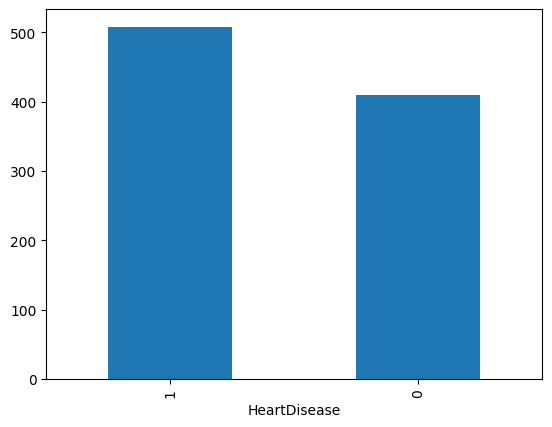

In [ ]:
df['HeartDisease'].value_counts().plot(kind='bar')
# data me 0 , 1 equally distributed hoto model zyada acha banta hai

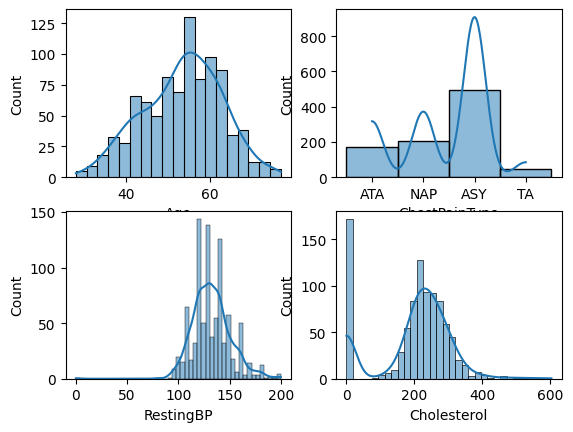

In [ ]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

# subplot used to make multiple graphs like this into a single canvas we need to mention the numbers beside so it can understand which graph to place where and 2,2 is the 2 rows 2 coloumns for graph

plotting('Age',1)
plotting('ChestPainType',2)
plotting('RestingBP',3)
plotting('Cholesterol',4)

In [ ]:
# yaha se hame pata chal raha hai ki cholestrol or bp 0 hai but google par search kiya to pata chala aisa kabhi ho hi nahi sakta so they are wrong data entries
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [ ]:
ch_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [ ]:
df['Cholesterol']=df['Cholesterol'].replace({
    0:ch_mean
})
df['Cholesterol']=df['Cholesterol'].round()

In [ ]:
resting_bp=df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df['RestingBP']=df['RestingBP'].replace({
    0:resting_bp
})
df['RestingBP']=df['RestingBP'].round()

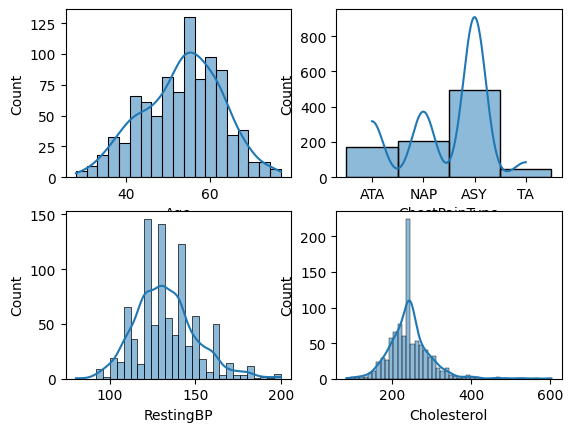

In [ ]:

plotting('Age',1)
plotting('ChestPainType',2)
plotting('RestingBP',3)
plotting('Cholesterol',4)

<Axes: xlabel='ChestPainType', ylabel='count'>

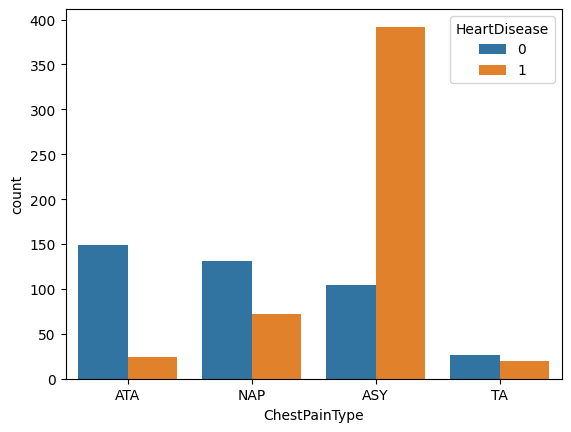

In [ ]:
sns.countplot(x= df['ChestPainType'],hue=df['HeartDisease'])
# since the output data of ours is in 0 , 1 we can use hue here

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

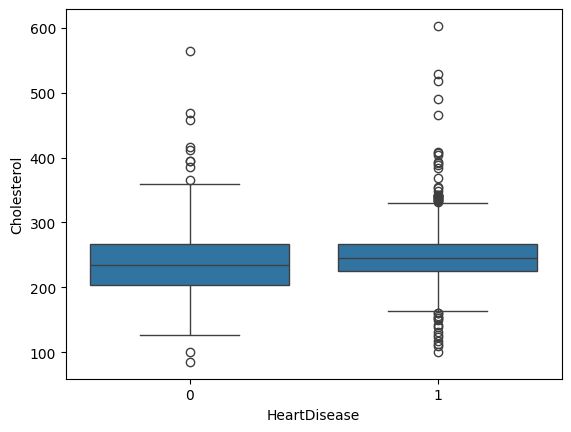

In [ ]:
# Boxplot can compare between numeric variable and string varible
sns.boxplot(x=df['HeartDisease'], y=df['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

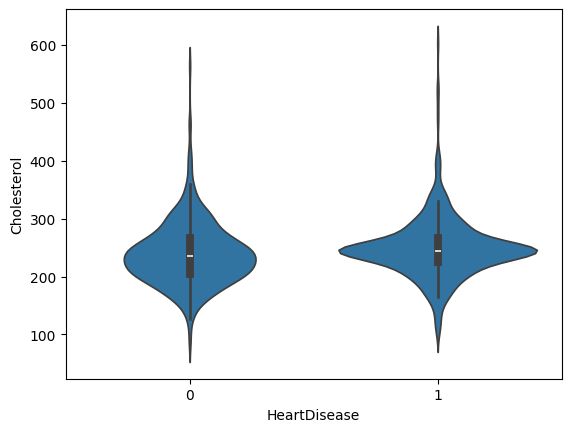

In [ ]:
sns.violinplot(x=df['HeartDisease'], y=df['Cholesterol'],data=df)

In [ ]:
df_encode= pd.get_dummies(df,drop_first=True)
df_encode.astype(int)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [ ]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414825,0.831244,0,1.382928,-0.832432,0,True,True,False,False,True,False,False,False,True
1,-0.478484,1.527163,-1.214200,0,0.754157,0.105664,1,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.141345,0.718651,0,-1.525138,-0.832432,0,True,True,False,False,False,True,False,False,True
3,-0.584556,0.303591,-0.576172,0,-1.132156,0.574711,1,False,False,False,False,True,False,True,True,False
4,0.051881,0.970994,-0.932717,0,-0.581981,-0.832432,0,True,False,True,False,True,False,False,False,True


In [ ]:
heactclean =df_encode.to_csv('heart_clean.csv',index=False)

In [ ]:
# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Support Vector Machine
from sklearn.svm import SVC

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [ ]:
X=df_encode.drop('HeartDisease',axis=1)
y=df_encode['HeartDisease']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
scaler=StandardScaler()
# kyonki sare models me feature scaling karni padti hai

In [ ]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [ ]:
models={
    'KNN':KNeighborsClassifier(),
    'LR':LogisticRegression(),
    'DT':DecisionTreeClassifier(),
    'RF':RandomForestClassifier(),
    'SVM':SVC()
}

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
result=[]
for name,model in models.items():
  model.fit(X_train_scaled,y_train)
  y_pred=model.predict(X_test_scaled)
  acc=accuracy_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred)
  result.append({
      "model":name,
      'accuracy':acc,
      'f1_score':f1
  })


In [ ]:
result

[{'model': 'KNN',
  'accuracy': 0.8532608695652174,
  'f1_score': 0.8708133971291866},
 {'model': 'LR',
  'accuracy': 0.8641304347826086,
  'f1_score': 0.8792270531400966},
 {'model': 'DT',
  'accuracy': 0.8152173913043478,
  'f1_score': 0.8333333333333334},
 {'model': 'RF',
  'accuracy': 0.8695652173913043,
  'f1_score': 0.8878504672897196},
 {'model': 'SVM',
  'accuracy': 0.8586956521739131,
  'f1_score': 0.8761904761904762}]

In [ ]:
import joblib
joblib.dump(models['KNN'],'KNN_Heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']